# Baseline 訓練 — 單階段 9 類分類
每個 Cell 對應一個獨立步驟，可分開執行：
- **Cell 1**：環境設定（只需執行一次）
- **Cell 2**：實驗設定（換參數只改這裡，改完重跑 Cell 4+）
- **Cell 3**：載入資料（只需執行一次，換設定不需重跑）
- **Cell 4**：準備資料集與模型
- **Cell 5**：訓練（含即時圖表）
- **Cell 6**：測試集評估
- **Cell 7**：最終圖表
- **Cell 8**：儲存結果（選用）

In [1]:
import sys
sys.path.insert(0, '..')
# Cell 1 — 環境設定（只需執行一次）
%matplotlib inline
import copy
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from tabulate import tabulate

from engine.trainer import print_metrics, print_per_class_f1, run_one_epoch, train_model
from engine.visualize import plot_cm, plot_history
from models.builder import build_model
from constant import LABEL_MAP, MODELS
from data.dataset import WaferDataset, extract_labeled_patterned_data, load_raw_data, make_dataloaders, split_df, undersample_none
from utils import make_output_dir, save_results, EpochTimer


device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)
print(f"使用裝置：{device}")

/Users/fe-edward/wafer-map-detection/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


使用裝置：mps


In [2]:
# Cell 2 — 實驗設定（換參數只改這裡，改完重跑 Cell 4+）
EXPERIMENT_NAME    = "baseline_b4"
MODEL_NAME         = "efficientnet_b4"
IMAGE_SIZE         = (64,64)
BATCH_SIZE         = 32
EPOCHS             = 24
LR                 = 1e-3
RANDOM_SEED        = 42

In [3]:
# Cell 3 — 載入資料（只需執行一次，換設定不用重跑）
print("下載/讀取 WM-811K 資料集...")
df = load_raw_data()
df_with_label, df_with_pattern, _ = extract_labeled_patterned_data(df)
print(f"有標籤資料：{len(df_with_label)} 筆")

下載/讀取 WM-811K 資料集...
有標籤資料：172950 筆


In [4]:
# Cell 4 — 準備資料集與模型
train_df, val_df, test_df = split_df(
    df_with_label, stratify_col="failureType", random_seed=RANDOM_SEED,
)

num_classes = len(LABEL_MAP)
datasets = {
    "train": WaferDataset(train_df, image_size=IMAGE_SIZE),
    "val":   WaferDataset(val_df, image_size=IMAGE_SIZE),
    "test":  WaferDataset(test_df, image_size=IMAGE_SIZE),
}
dataloaders = make_dataloaders(datasets, BATCH_SIZE)

model = build_model(num_classes, device, model_name=MODEL_NAME)
criterion = nn.CrossEntropyLoss()
params = filter(lambda p: p.requires_grad, model.parameters())
optimizer = AdamW(params, lr=LR)
scheduler = ReduceLROnPlateau(optimizer, mode="max", patience=2, factor=0.5)
print(f"模型與資料集準備完成，類別數：{num_classes}")

模型與資料集準備完成，類別數：9


In [5]:
# Cell 5 — 訓練
timer = EpochTimer()
min_loss_seen = 100
def store_min_loss_seen(val_m, history, epoch):
  timer(val_m, history, epoch)
  global min_loss_seen
  if val_m["loss"] < min_loss_seen:
    min_loss_seen = val_m["loss"]

def loss_guard(val_m, history, epoch):
  return val_m["loss"] <= min_loss_seen * 1.05 # loss 不能超過最小 loss 的 1.05 倍

best_state, best_f1, best_cm, best_f1_per_class, history = train_model(
    model, device, criterion, optimizer, scheduler, dataloaders,
    num_classes=num_classes,
    epochs=EPOCHS,
    lr=LR,
    epoch_callback=store_min_loss_seen,
    checkpoint_guard=loss_guard,
    early_stopping=True, patience=6,
)
print(f"\n訓練完成，最佳驗證 F1：{best_f1:.4f}")

time_per_epoch = timer.get_time_per_epoch()
print(f"Time per epoch: {time_per_epoch:.1f}s")


===== Epoch 1/24 =====
+---------+--------+--------+--------+-------------+----------+
| Split   |   Loss |     F1 |    Acc |   Precision |   Recall |
+=========+========+========+========+=============+==========+
| Train   | 0.2507 | 0.5707 | 0.9334 |      0.656  |   0.528  |
+---------+--------+--------+--------+-------------+----------+
| Val     | 0.1328 | 0.7681 | 0.9583 |      0.8041 |   0.7442 |
+---------+--------+--------+--------+-------------+----------+
+----------+---------+------------+-------------+--------+-------------+----------+-----------+--------+
|   Center |   Donut |   Edge-Loc |   Edge-Ring |    Loc |   Near-full |   Random |   Scratch |   none |
+==========+=========+============+=============+========+=============+==========+===========+========+
|   0.8371 |  0.7194 |     0.6596 |      0.9587 | 0.6138 |      0.7317 |   0.8464 |     0.561 | 0.9848 |
+----------+---------+------------+-------------+--------+-------------+----------+-----------+--------+

===

In [6]:
# Cell 6 — 測試集評估
model.load_state_dict(best_state)
test_m = run_one_epoch(model, device, dataloaders["test"], criterion, num_classes=num_classes)
print("\n--- Test Results ---")
print(tabulate(
    [[f"{test_m['loss']:.4f}", f"{test_m['f1']:.4f}",
      f"{test_m['acc']:.4f}", f"{test_m['precision']:.4f}", f"{test_m['recall']:.4f}"]],
    headers=["Loss", "F1", "Acc", "Precision", "Recall"],
    tablefmt="grid",
))
print("\n--- Per-Class F1 ---")
print_per_class_f1(test_m["per_class_f1"])


--- Test Results ---
+--------+--------+--------+-------------+----------+
|   Loss |     F1 |    Acc |   Precision |   Recall |
+========+========+========+=============+==========+
| 0.0895 | 0.8624 | 0.9704 |       0.854 |   0.8774 |
+--------+--------+--------+-------------+----------+

--- Per-Class F1 ---
+----------+---------+------------+-------------+--------+-------------+----------+-----------+--------+
|   Center |   Donut |   Edge-Loc |   Edge-Ring |    Loc |   Near-full |   Random |   Scratch |   none |
+==========+=========+============+=============+========+=============+==========+===========+========+
|   0.9117 |  0.8383 |     0.7896 |      0.9754 | 0.7283 |      0.9545 |   0.8843 |    0.6912 | 0.9878 |
+----------+---------+------------+-------------+--------+-------------+----------+-----------+--------+


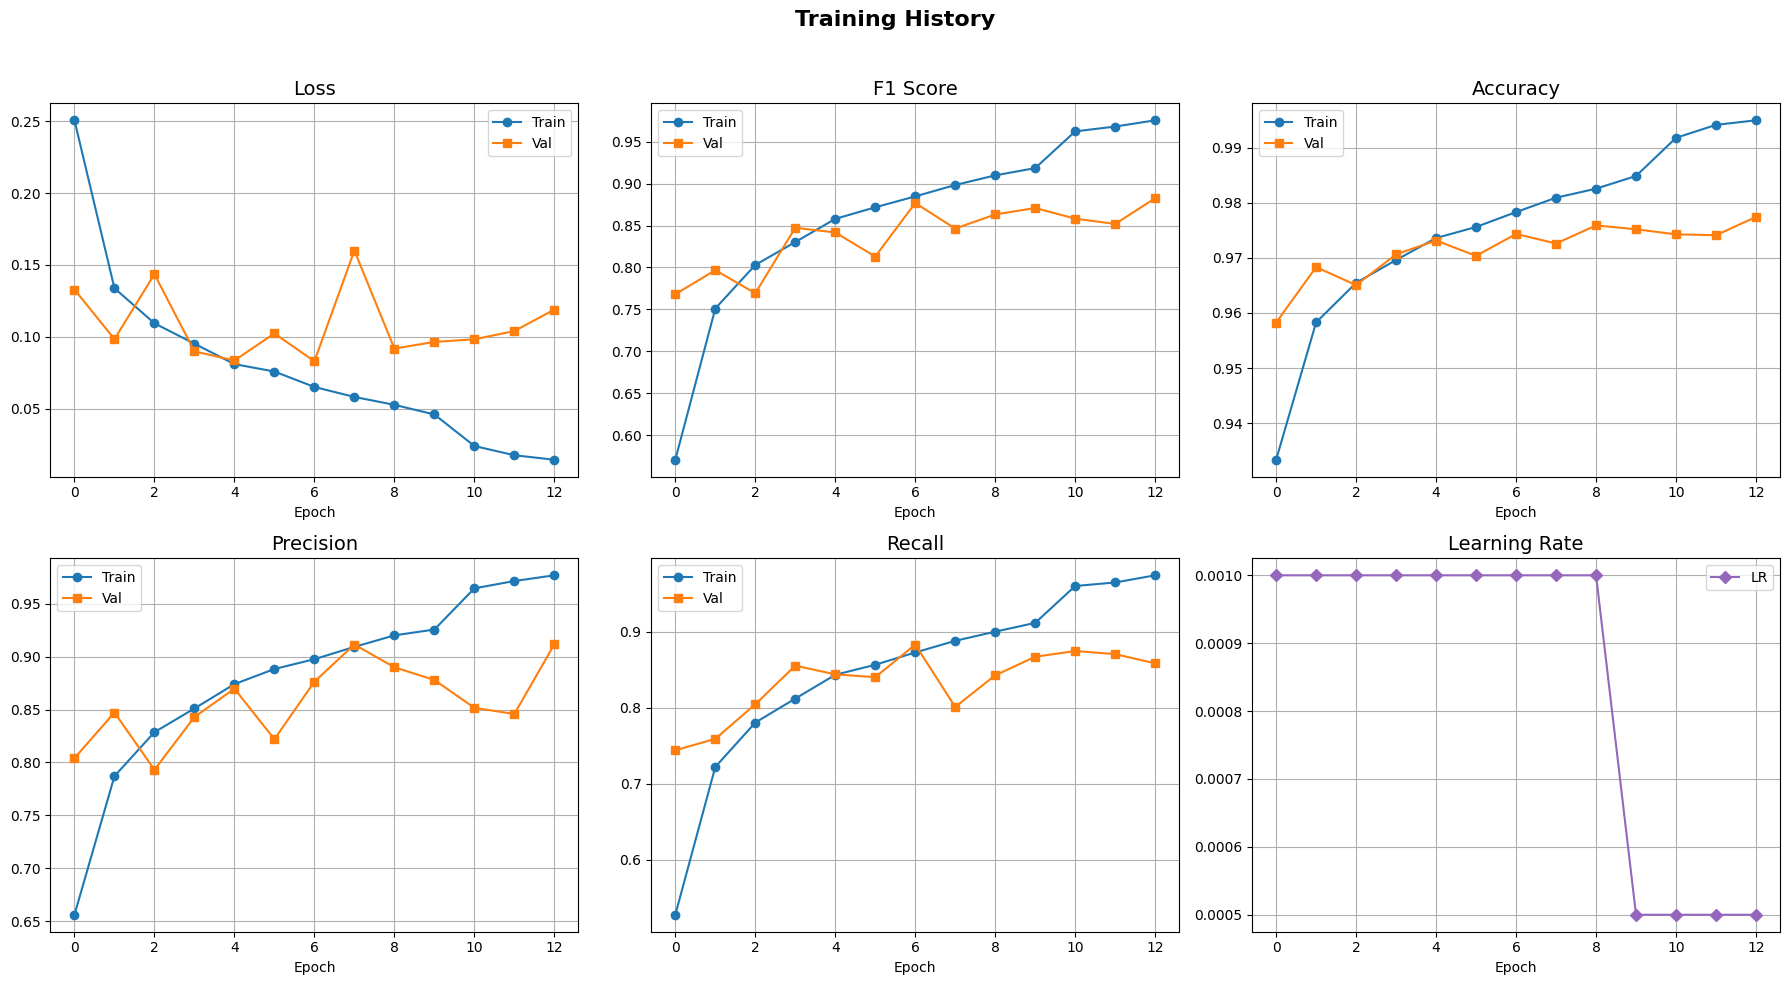

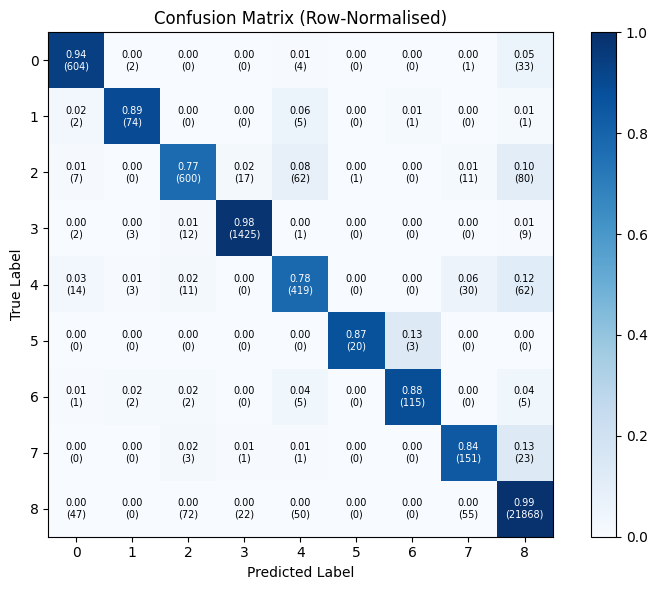


--- Best Val Per-Class F1 ---
+----------+---------+------------+-------------+--------+-------------+----------+-----------+--------+
|   Center |   Donut |   Edge-Loc |   Edge-Ring |    Loc |   Near-full |   Random |   Scratch |   none |
+==========+=========+============+=============+========+=============+==========+===========+========+
|   0.9145 |  0.8862 |     0.8119 |       0.977 | 0.7716 |      0.9091 |   0.9237 |    0.7073 | 0.9896 |
+----------+---------+------------+-------------+--------+-------------+----------+-----------+--------+


In [7]:
# Cell 7 — 最終圖表
plot_history(history, show=True)
plot_cm(best_cm, num_classes, show=True)
print("\n--- Best Val Per-Class F1 ---")
print_per_class_f1(best_f1_per_class)

In [8]:
# 推論運行時間
import time

from models.inference import predict
from explain import preprocess_wafer

# 量測單樣本推論時間
model.load_state_dict(best_state)
model.eval()
sample_input = test_df.iloc[0]
preprocessed_wafer, _ = preprocess_wafer(sample_input["waferMap"], IMAGE_SIZE, device)

with torch.no_grad():  # warmup
    _ = predict(model, preprocessed_wafer)
if device.type == "cuda":
    torch.cuda.synchronize()
elif device.type == "mps":
    torch.mps.synchronize()

N = 100
with torch.no_grad():
    t0 = time.perf_counter()
    for _ in range(N):
        _ = predict(model, preprocessed_wafer)
    if device.type == "cuda":
        torch.cuda.synchronize()
    elif device.type == "mps":
        torch.mps.synchronize()
    t1 = time.perf_counter()

inference_time = (t1 - t0) / N * 1000  # ms per sample
print(f"單樣本推論時間（{N} 次平均）：{inference_time:.3f} ms")

單樣本推論時間（100 次平均）：12.907 ms


In [ ]:
# Cell 8 — 儲存結果（選用）


out_dir = make_output_dir(EXPERIMENT_NAME, base="../outputs")
save_results(
    out_dir, model, best_state, best_f1, best_cm, best_f1_per_class,
    history, num_classes, LABEL_MAP, IMAGE_SIZE, time_per_epoch,
    inference_time=inference_time, model_name=MODEL_NAME
)
print(f"結果已儲存至：{out_dir}")

Results saved to ../outputs/baseline_b4_20260607_174901
結果已儲存至：../outputs/baseline_b4_20260607_174901


**baseline_20260525_204323** 訓練結果筆記

發現：
- epoch 18 之後，觸發學習率下降，但也導致 val loss 飆升。模型最終取用的最高 F1 分數，是 epoch 22，也就是 val loss 已經飆升後的模型參數。
- 有 3 類別(Edge-Loc, Loc, Scratch) 的 F1 低於平均 F1，也就是模型對於這幾個類別有較低的辨識度，容易辨識錯誤，且各自都最常誤認為 none 類別。

可能的解決辦法：
- 模式辨認混淆問題，可以用二階段辨認。
- val loss 飆升問題，改用「loss 最小化」來訓練模型，看結果會不會跟「F1 最大化」的訓練結果差不多。
- val loss 飆升問題，是否也可以用接續訓練的方式，且 backbone 層的學習率設定小一點。是否可有在loss不飆升的情況下，持續以「F1 最大化」來訓練優化模型。

**baseline_20260530_211352** 訓練結果筆記

改動：
- IMAGE_SIZE (32, 32) -> (64,64)
- add loss guard to prevent high loss model state been adapted
- early stop

結果：
- best f1: 0.87
- Scratch class f1: 0.73
- epoch 14 stop learning

發現：
- 從 epoch 7, 8 loss 就幾乎不再下降，F1 也幾乎不再有顯著上升，停在 0.85 附近。

In [10]:
from explain import load_model, explain_samples
from pytorch_grad_cam import GradCAM

# out_dir = "outputs/baseline_20260530_211352"

model, metadata = load_model(f"{out_dir}")

print(metadata)

{'model_name': 'efficientnet_b4', 'num_parameters': 17.564753, 'num_classes': 9, 'class_to_idx': {'Center': 0, 'Donut': 1, 'Edge-Loc': 2, 'Edge-Ring': 3, 'Loc': 4, 'Near-full': 5, 'Random': 6, 'Scratch': 7, 'none': 8}, 'img_size': [64, 64], 'best_epoch': 6, 'best_val_f1': 0.8767693735512688, 'per_class_f1': [0.9144587433762301, 0.8862275449101796, 0.8119079837618404, 0.9770311964346932, 0.7716390423572744, 0.9090909090909091, 0.9236947791164659, 0.7072599531615925, 0.9896142097522345], 'train_time_per_epoch': 2355.589854148718, 'inference_time': 12.906768750399351, 'val_train_loss_gap': 0.017876726612742866}


In [11]:
img_h, img_w = metadata["img_size"][0], metadata["img_size"][1]
device = next(model.parameters()).device

dummy_data = torch.randn(1,3,img_h,img_w).to(device)

x = dummy_data
for i, layer in enumerate(model.features):
  x = layer(x)
  print(f"features.{i} output shape: {x.shape}")

features.0 output shape: torch.Size([1, 48, 32, 32])
features.1 output shape: torch.Size([1, 24, 32, 32])
features.2 output shape: torch.Size([1, 32, 16, 16])
features.3 output shape: torch.Size([1, 56, 8, 8])
features.4 output shape: torch.Size([1, 112, 4, 4])
features.5 output shape: torch.Size([1, 160, 4, 4])
features.6 output shape: torch.Size([1, 272, 2, 2])
features.7 output shape: torch.Size([1, 448, 2, 2])
features.8 output shape: torch.Size([1, 1792, 2, 2])


Saved to ../outputs/baseline_b4_20260607_174901/grad-cam.png


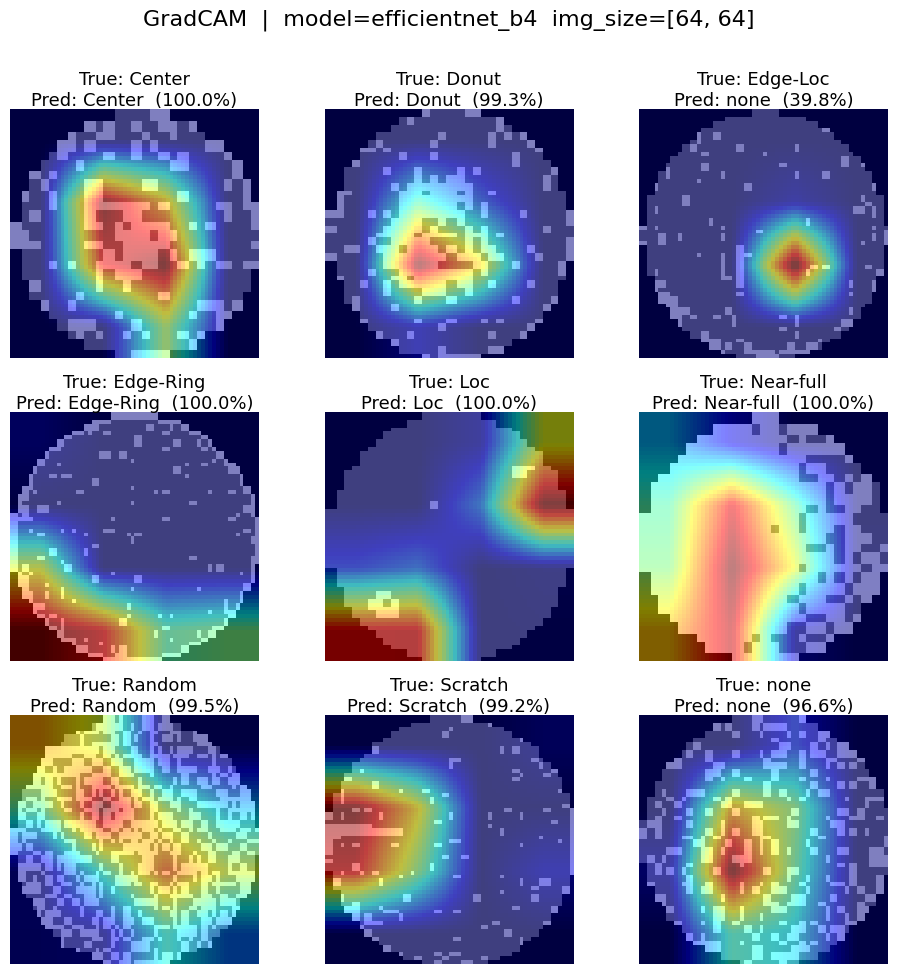

: 

In [ ]:
target_layer = model.features[5]

cam = GradCAM(model=model, target_layers=[target_layer])
explain_samples(cam, metadata, df, RANDOM_SEED, save_path=f"{out_dir}/grad-cam.png")

**baseline_b2_20260606_095534** 訓練結果筆記

改動：
- 改成使用 efiicientnet_b2 模型遷移學習

結果：
|    | b2 | b4 |
| -- | -- | -- |
| best val f1 | 0.875 | 0.865 |
| Scratch class f1 | 0.735 | 0.735 |
| stop learning epoch | 12 | 14 |
- inference_time: 8.29 ms
- train_time_per_epoch: 501.14 s